In [1]:
import hashlib
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import Counter, namedtuple
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [27]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
codebert_model = AutoModel.from_pretrained("microsoft/codebert-base")

batch_size = 8
num_epochs = 10
learning_rate = 1e-5
weight_decay = 0.05
class_weights = torch.tensor([1.9, 0.68])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [28]:
class CodeBERTTDetection(nn.Module):
  def __init__(self, codebert):
    super(CodeBERTTDetection, self).__init__()

    self.codebert = codebert
    self.dropout1 = nn.Dropout(p=0.2)
    self.linear1 = nn.Linear(768, 3072)
    self.tanh = nn.Tanh()
    self.dropout2 = nn.Dropout(p=0.2)
    self.linear2 = nn.Linear(3072, 3072)
    self.classifier = nn.Linear(3072, 2)

    self.loss_func = nn.CrossEntropyLoss(weight=class_weights)
    # self.loss_func = nn.BCEWithLogitsLoss(weight=class_weights)

  def forward(self, input_ids, attention_mask):
    output = self.codebert(input_ids = input_ids, attention_mask = attention_mask)
    output = torch.mean(output.last_hidden_state, 1)
    output = self.dropout1(output)
    output = self.linear1(output)
    output = self.tanh(output)
    output = self.dropout2(output)
    output = self.linear2(output)
    output = self.classifier(output)

    return output

In [29]:
def clean_data(text_samples, labels):
  hashmap = {}
  temp_list = []

  for i in range(len(text_samples)):
    sample_digest = hashlib.sha256(text_samples[i].encode('utf-8')).hexdigest()

    if hashmap.get(sample_digest) == None:
      hashmap[sample_digest] = (labels[i], i)
    else:
      if hashmap[sample_digest][0] != labels[i] and (sample_digest not in temp_list):
        temp_list.append(sample_digest)

  for x in temp_list:
    hashmap.pop(x)

  values = hashmap.values()

  cleaned_samples = [text_samples[val[1]] for val in values]
  cleaned_labels = [labels[val[1]] for val in values]

  return cleaned_samples, cleaned_labels

In [30]:
class VulnDataset(Dataset):
    def __init__(self, file_name, tokenizer):
        self.tokenizer = tokenizer

        with open(file_name) as f:
            raw_data = f.read()

        raw_data = raw_data.split("---------------------------------\n")

        self.samples = []
        self.labels = []

        for sample in raw_data:
            sample = sample.strip().split("\n")[1:]

            if len(sample) < 3:
                continue

            self.samples.append("\n".join(sample[:-1]))
            self.labels.append(int(sample[-1]))

        self.samples, self.labels = clean_data(self.samples, self.labels)

        self.encodings = tokenizer(
            self.samples,
            padding=True,
            truncation=True,
            max_length=512
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encodings["input_ids"][idx]),
            torch.tensor(self.encodings["attention_mask"][idx]),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

In [31]:
dataset = VulnDataset("cwe119.txt", tokenizer)
print("Full data-set size:", len(dataset))

Full data-set size: 19904


In [32]:
dataset = torch.utils.data.random_split(dataset, [0.8, 0.1, 0.1])
train_dataset = dataset[0]
test_dataset = dataset[1]
validation_dataset = dataset[2]
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Validation size:", len(validation_dataset))

Train size: 15924
Test size: 1990
Validation size: 1990


In [38]:
train_labels = [train_dataset.dataset.labels[i] for i in train_dataset.indices]
test_labels = [test_dataset.dataset.labels[i] for i in test_dataset.indices]

print("Train:", Counter(train_labels))
print("Test:", Counter(test_labels))

Train: Counter({0: 9796, 1: 6128})
Test: Counter({0: 1200, 1: 790})


In [33]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)

In [34]:
model = CodeBERTTDetection(codebert_model)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [35]:
def plot_graph(x_axis, y_axis, x_label, y_label, title):
  plt.plot(x_axis, y_axis)
  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.title(title)
  plt.grid()
  plt.show()

In [36]:
def evaluate(dataloader):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in dataloader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask)

            predictions = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

    matrix = confusion_matrix(all_labels, all_predictions, labels=[0, 1])

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)

    tn, fp, fn, tp = matrix.ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    RetType = namedtuple(
        "RetType",
        ["accuracy", "precision", "recall", "f1_score", "fpr", "fnr"],
    )

    return RetType(accuracy, precision, recall, f1, fpr, fnr)

Before Training ...

In [37]:
evaluate(test_dataloader)

RetType(accuracy=0.6025125628140704, precision=0.0, recall=0.0, f1_score=0.0, fpr=np.float64(0.0008333333333333334), fnr=np.float64(1.0))

In [39]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

print(class_weights)

tensor([0.8128, 1.2993], device='cuda:0')


In [40]:
predictions = []

model.eval()
with torch.no_grad():
    for input_ids, attention_mask, labels in test_dataloader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().tolist())

print(Counter(predictions))

Counter({0: 1989, 1: 1})


Epoch: 1, Progress: 7964/15924; 50.01%, Loss Avg: 0.1785, Current Batch Loss: 0.0281
Evaluating Epoch Performance...
Epoch 1 performance metrics:
Accuracy: 0.9442
Precision: 0.9857
Recall: 0.8722
F1 Score: 0.9255
False Positive Rate: 0.0083
False Negative Rate: 0.1278


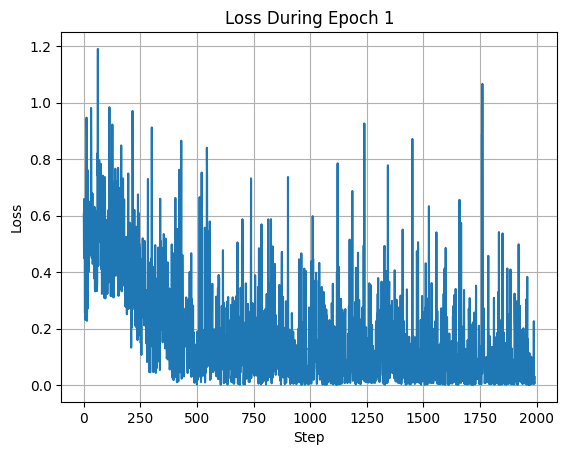

Epoch: 2, Progress: 7964/15924; 50.01%, Loss Avg: 0.0787, Current Batch Loss: 0.0207
Evaluating Epoch Performance...
Epoch 2 performance metrics:
Accuracy: 0.9568
Precision: 0.9744
Recall: 0.9152
F1 Score: 0.9439
False Positive Rate: 0.0158
False Negative Rate: 0.0848


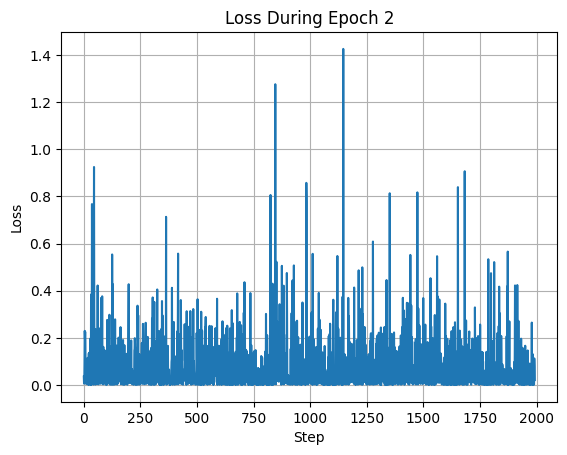

Epoch: 3, Progress: 7964/15924; 50.01%, Loss Avg: 0.0596, Current Batch Loss: 0.0503
Evaluating Epoch Performance...
Epoch 3 performance metrics:
Accuracy: 0.9663
Precision: 0.9605
Recall: 0.9544
F1 Score: 0.9575
False Positive Rate: 0.0258
False Negative Rate: 0.0456


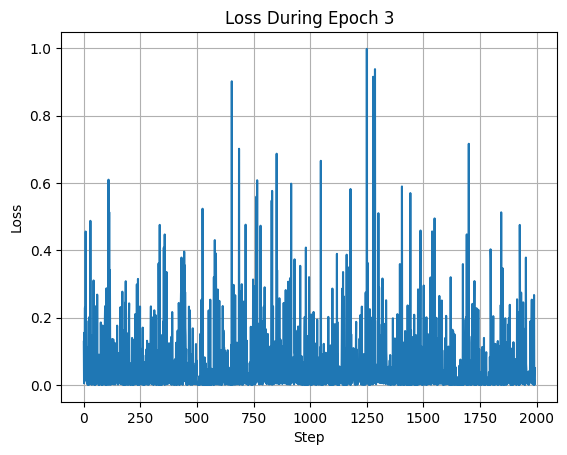

Epoch: 4, Progress: 7964/15924; 50.01%, Loss Avg: 0.0454, Current Batch Loss: 0.0002
Evaluating Epoch Performance...
Epoch 4 performance metrics:
Accuracy: 0.9653
Precision: 0.9652
Recall: 0.9468
F1 Score: 0.9559
False Positive Rate: 0.0225
False Negative Rate: 0.0532


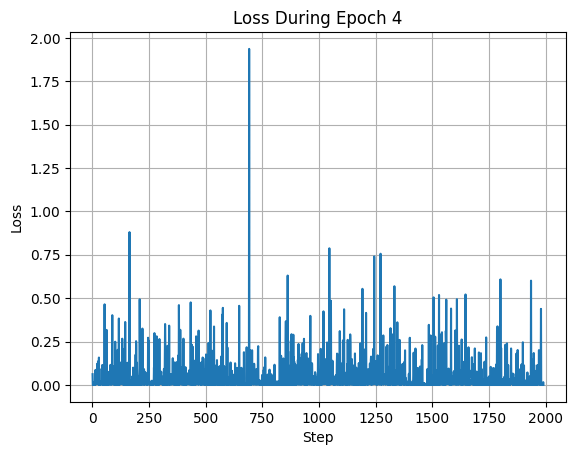

Epoch: 5, Progress: 7952/15924; 49.94%, Loss Avg: 0.0303, Current Batch Loss: 0.0002

KeyboardInterrupt: 

In [41]:
def train():
    loss_values = []

    for epoch in range(num_epochs):
        model.train()

        loss_values.append([])
        batch_count = 0

        for input_ids, attention_mask, labels in train_dataloader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device).long()

            optimizer.zero_grad()

            outputs = model(input_ids, attention_mask)
            loss = model.loss_func(outputs, labels)

            loss.backward()
            optimizer.step()

            batch_count += 1
            loss_values[epoch].append(loss.item())

            processed = batch_count * len(input_ids)

            print(
                "\rEpoch: {}, Progress: {}/{}; {:.2f}%, Loss Avg: {:.4f}, Current Batch Loss: {:.4f}".format(
                    epoch + 1,
                    processed,
                    len(train_dataset),
                    (processed / len(train_dataset)) * 100,
                    sum(loss_values[epoch]) / len(loss_values[epoch]),
                    loss.item()
                ),
                end=""
            )

        print("\nEvaluating Epoch Performance...")

        eval_result = evaluate(test_dataloader)

        print(
            "Epoch {} performance metrics:\n"
            "Accuracy: {:.4f}\n"
            "Precision: {:.4f}\n"
            "Recall: {:.4f}\n"
            "F1 Score: {:.4f}\n"
            "False Positive Rate: {:.4f}\n"
            "False Negative Rate: {:.4f}".format(
                epoch + 1,
                eval_result.accuracy,
                eval_result.precision,
                eval_result.recall,
                eval_result.f1_score,
                eval_result.fpr,
                eval_result.fnr
            )
        )

        plot_graph(
            list(range(1, len(loss_values[epoch]) + 1)),
            loss_values[epoch],
            'Step',
            'Loss',
            f'Loss During Epoch {epoch + 1}'
        )

    print("Done.")

    y_axis = []
    for l in loss_values:
        y_axis += l

    x_axis = list(range(1, len(y_axis) + 1))

    plot_graph(
        x_axis,
        y_axis,
        'Step',
        'Loss',
        'Loss During Training'
    )

train()

After training ...

In [42]:
evaluate(test_dataloader)

RetType(accuracy=0.964824120603015, precision=0.9774535809018567, recall=0.9329113924050633, f1_score=0.9546632124352331, fpr=np.float64(0.014166666666666666), fnr=np.float64(0.0670886075949367))

In [43]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

print(class_weights)

tensor([0.8128, 1.2993], device='cuda:0')


In [44]:
predictions = []

model.eval()
with torch.no_grad():
    for input_ids, attention_mask, labels in test_dataloader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().tolist())

print(Counter(predictions))

Counter({0: 1236, 1: 754})
